===== DATA PREVIEW =====
           Region       Date Frequency  Unemployment  Estimated Employed  \
0  Andhra Pradesh 2019-05-31   Monthly          3.65          11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly          3.05          11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly          3.75          12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly          3.32          12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly          5.17          12256762.0   

   Estimated Labour Participation Rate (%)   Area  
0                                    43.24  Rural  
1                                    42.05  Rural  
2                                    43.50  Rural  
3                                    43.97  Rural  
4                                    44.68  Rural  

===== DATA INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------  

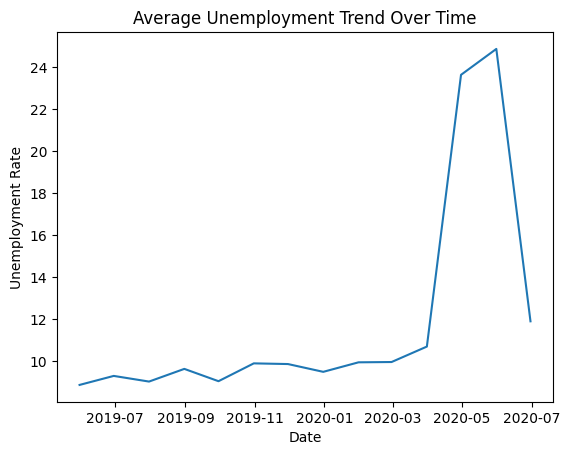


===== REGION ANALYSIS =====


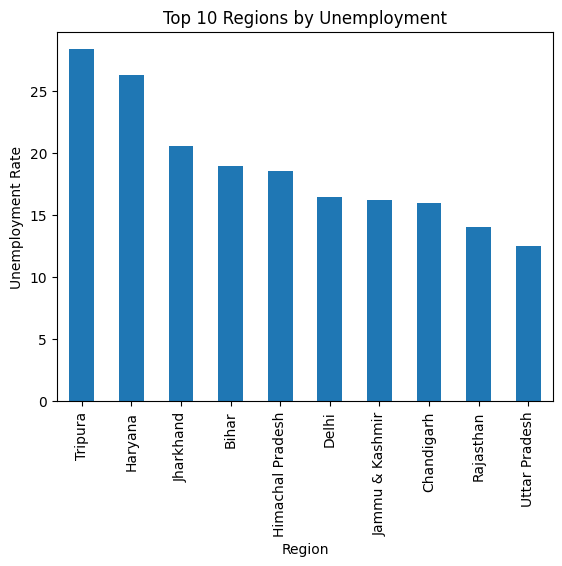


===== AREA ANALYSIS =====


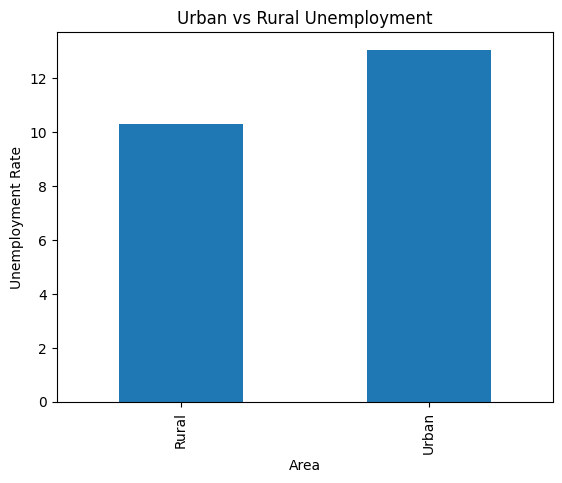


===== COVID IMPACT =====
Pre-COVID Avg: 9.40%
During-COVID Avg: 15.10%
Increase: 5.70%


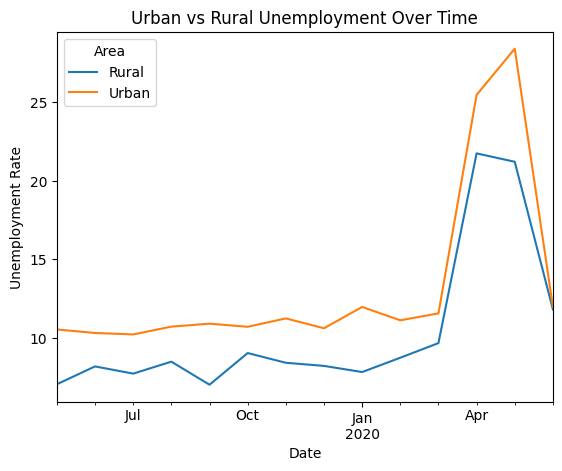


===== FINAL INSIGHTS =====

1. Unemployment stable before 2020 (~9–10%)
2. Sharp spike during COVID (~25%)
3. Highest unemployment: Tripura, Haryana
4. Lowest unemployment: Meghalaya, Odisha
5. Urban > Rural unemployment
6. COVID impact clearly visible in data



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ===================== LOAD DATA =====================
data = pd.read_csv("C:/Users/PC/Downloads/archive/Unemployment in India.csv")

# ===================== CLEAN DATA =====================
data.columns = data.columns.str.strip()

data.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment"
}, inplace=True)

data["Date"] = pd.to_datetime(data["Date"], dayfirst=True)

# ===================== HANDLE MISSING VALUES =====================

# Fill numeric columns
data["Unemployment"] = data["Unemployment"].fillna(data["Unemployment"].mean())
data["Estimated Employed"] = data["Estimated Employed"].fillna(data["Estimated Employed"].mean())
data["Estimated Labour Participation Rate (%)"] = data[
    "Estimated Labour Participation Rate (%)"
].fillna(data["Estimated Labour Participation Rate (%)"].mean())

# Fill categorical columns
data["Region"] = data["Region"].fillna(data["Region"].mode()[0])
data["Area"] = data["Area"].fillna(data["Area"].mode()[0])
data["Frequency"] = data["Frequency"].fillna(data["Frequency"].mode()[0])

# Missing values handled using mean (numeric) and mode (categorical)
# This preserves dataset size and reduces bias

# ===================== BASIC INFO =====================
print("===== DATA PREVIEW =====")
print(data.head())

print("\n===== DATA INFO =====")
data.info()

print("\n===== STATISTICS =====")
print(data.describe())

# ===================== TIME ANALYSIS =====================
avg_data = data.groupby("Date")["Unemployment"].mean()

plt.plot(avg_data)
plt.title("Average Unemployment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.savefig("trend.png")
plt.show()

# Insight:
# Unemployment was stable (~9–10%) before 2020
# Sharp spike (~25%) during COVID lockdown
# Partial recovery after spike

# ===================== REGION ANALYSIS =====================
print("\n===== REGION ANALYSIS =====")

region_data = data.groupby("Region")["Unemployment"].mean().sort_values(ascending=False)

region_data.head(10).plot(kind="bar")
plt.title("Top 10 Regions by Unemployment")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate")
plt.savefig("region.png")
plt.show()

# Insight:
# Tripura and Haryana have highest unemployment
# Meghalaya and Odisha have lowest
# Northern regions generally higher

# ===================== AREA ANALYSIS =====================
print("\n===== AREA ANALYSIS =====")

area_data = data.groupby("Area")["Unemployment"].mean()

area_data.plot(kind="bar")
plt.title("Urban vs Rural Unemployment")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate")
plt.savefig("area.png")
plt.show()

# Insight:
# Urban unemployment (~13%) higher than rural (~10%)

# ===================== COVID IMPACT =====================
data["Year"] = data["Date"].dt.year

pre_covid = data[data["Year"] < 2020]["Unemployment"].mean()
during_covid = data[data["Year"] >= 2020]["Unemployment"].mean()

print("\n===== COVID IMPACT =====")
print(f"Pre-COVID Avg: {pre_covid:.2f}%")
print(f"During-COVID Avg: {during_covid:.2f}%")
print(f"Increase: {during_covid - pre_covid:.2f}%")

# Insight:
# COVID significantly increased unemployment levels

# ===================== AREA TREND =====================
area_trend = data.groupby(["Date", "Area"])["Unemployment"].mean().unstack()

area_trend.plot()
plt.title("Urban vs Rural Unemployment Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.savefig("area_trend.png")
plt.show()

# Insight:
# Urban unemployment spikes more sharply than rural during COVID
# Urban remains higher over time

# ===================== FINAL SUMMARY =====================
print("\n===== FINAL INSIGHTS =====")

print("""
1. Unemployment stable before 2020 (~9–10%)
2. Sharp spike during COVID (~25%)
3. Highest unemployment: Tripura, Haryana
4. Lowest unemployment: Meghalaya, Odisha
5. Urban > Rural unemployment
6. COVID impact clearly visible in data
""")